# <center>Category 2: Descriptive Analysis</center>

### 1. What is the average resting heart rate, and how frequently does it exceed 100 bpm (tachycardia)?

##### **Reason:** This question helps identify the typical resting heart rate of patients and how often it exceeds 100 bpm (tachycardia). Heart rate is an important indicator of physical stress and autonomic nervous system activity. In type 1 diabetes, tachycardia may indicate Diabetic Cardiovascular Autonomic Neuropathy (DCAN), a condition where high blood sugar damages the nerves controlling the heart. Frequent elevated heart rates, especially during low glucose events, may also suggest hypoglycemia associated autonomic responses (HAAF). Analyzing tachycardia frequency helps assess whether a patient’s cardiovascular system is frequently under stress.

*** Average Resting Heart Rate per Patient ***
patient_id
HUPA0001P    76.56
HUPA0002P    61.12
HUPA0003P    72.25
HUPA0004P    75.20
HUPA0005P    82.61
HUPA0006P    60.03
HUPA0007P    64.26
HUPA0009P    78.47
HUPA0010P    74.26
HUPA0011P    63.73
HUPA0014P    76.75
HUPA0015P    61.96
HUPA0016P    79.95
HUPA0017P    75.74
HUPA0018P    71.94
HUPA0019P    64.35
HUPA0020P    71.37
HUPA0021P    68.07
HUPA0022P    60.13
HUPA0023P    64.80
HUPA0024P    61.47
HUPA0025P    75.25
HUPA0026P    73.19
HUPA0027P    72.81
HUPA0028P    72.06
Name: heart_rate, dtype: float64

Overall Average Resting HR: 70.33 bpm

***Tachycardia Frequency per Patient (HR > 100 bpm) ***
            total_readings  tachycardia_readings  tachycardia_percentage
patient_id                                                              
HUPA0016P             3835                  1207                   31.47
HUPA0017P             3599                   491                   13.64
HUPA0014P             3829                   4

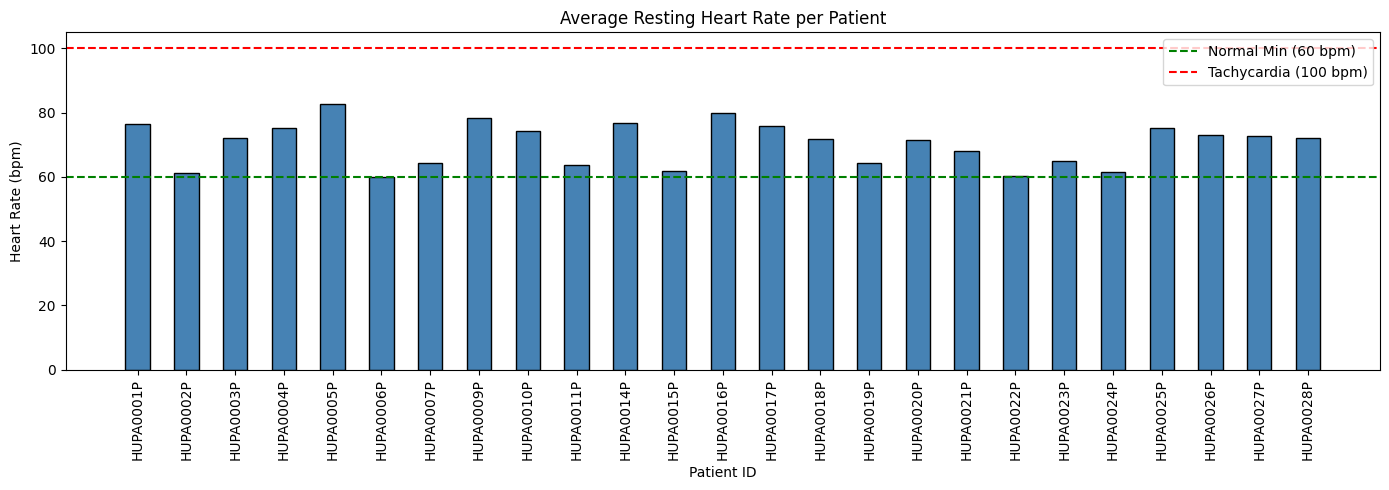

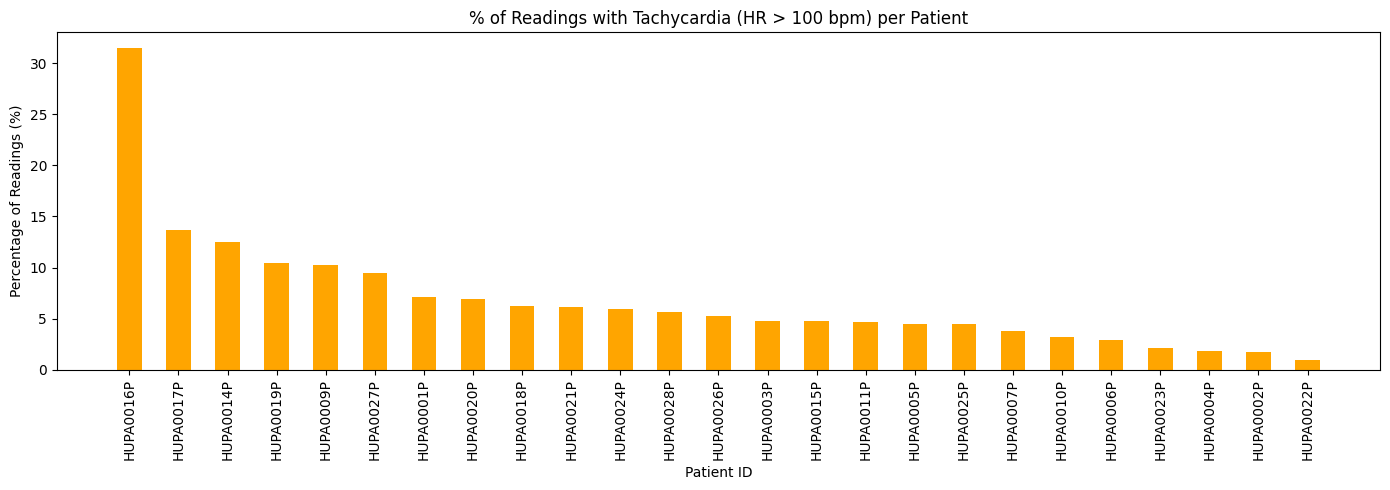

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Step 1 - Average resting heart rate per patient
# Resting = no physical activity (steps == 0)
resting_hr = df_all[df_all['steps'] == 0].groupby('patient_id')['heart_rate'].mean().round(2)

print("*** Average Resting Heart Rate per Patient ***")
print(resting_hr)
print(f"\nOverall Average Resting HR: {resting_hr.mean().round(2)} bpm")

# Step 2 - Tachycardia frequency per patient (heart rate > 100 bpm)
total_readings = df_all.groupby('patient_id')['heart_rate'].count()
tachycardia_readings = df_all[df_all['heart_rate'] > 100].groupby('patient_id')['heart_rate'].count()

tachycardia_summary = pd.DataFrame({
    'total_readings'          : total_readings,
    'tachycardia_readings'    : tachycardia_readings,
    'tachycardia_percentage'  : ((tachycardia_readings / total_readings) * 100).round(2)
}).fillna(0).sort_values('tachycardia_percentage', ascending=False)

print("\n***Tachycardia Frequency per Patient (HR > 100 bpm) ***")
print(tachycardia_summary)
print(f"\nPatient with highest tachycardia: "
      f"{tachycardia_summary['tachycardia_percentage'].idxmax()} "
      f"({tachycardia_summary['tachycardia_percentage'].max()}%)")

# Step 3 - Visualisation

# Plot 1 - Average resting heart rate per patient
x1 = resting_hr.index  # patient IDs
y1 = resting_hr.values  # average resting heart rate

plt.figure(figsize=(14, 5))
plt.bar(x1, y1, width=0.5, color='steelblue', edgecolor='black')
plt.axhline(y=60,  color='green', linestyle='--', linewidth=1.5, label='Normal Min (60 bpm)')
plt.axhline(y=100, color='red',   linestyle='--', linewidth=1.5, label='Tachycardia (100 bpm)')
plt.title('Average Resting Heart Rate per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Heart Rate (bpm)')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 - Tachycardia Percentage per Patient

x2 = tachycardia_summary.index           # patient IDs
y2 = tachycardia_summary['tachycardia_percentage']  # tachycardia %

plt.figure(figsize=(14, 5))
plt.bar(x2, y2, width=0.5, color='orange')
plt.title('% of Readings with Tachycardia (HR > 100 bpm) per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Percentage of Readings (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: Patient HUPA0016P had the highest tachycardia frequency at 31.47% followed by HUPA0017P </green>**

Question:Comparative Analysis of Health Metrics by Gender.What is the average glucose level and sleep quality for each gender within the dataset?

Reason for Analysis: This analysis is used to identify potential physiological differences or disparities in health outcomes between genders. By calculating the mean glucose and sleep quality, we can describe the baseline health status of male vs. female patients, which is crucial for personalized medical research or targeted healthcare interventions.


Comparative Analysis of Health Metrics by Gender
Question: What is the average glucose level and sleep quality for each gender within the dataset?

Reason for Analysis: This analysis is used to identify potential physiological differences or disparities in health outcomes between genders. By calculating the mean glucose and sleep quality, we can describe the baseline health status of male vs. female patients, which is crucial for personalized medical research or targeted healthcare interventions.

Diagnostic Analysis of Insulin Dosing Logic
Question: Is there a consistent linear relationship between carbohydrate intake and the insulin bolus delivered, and are there significant outliers in dosing behavior?

Reasoning: In diabetes management, insulin is usually delivered based on an Insulin-to-Carb Ratio (ICR). This diagnostic analysis uses a regression plot to visualize how strictly this rule is followed. By filtering out the "noise" (records with zero carbs or zero insulin), we can diagnose whether the dosing behavior is predictable or if there is high variance that might lead to unstable glucose levels.

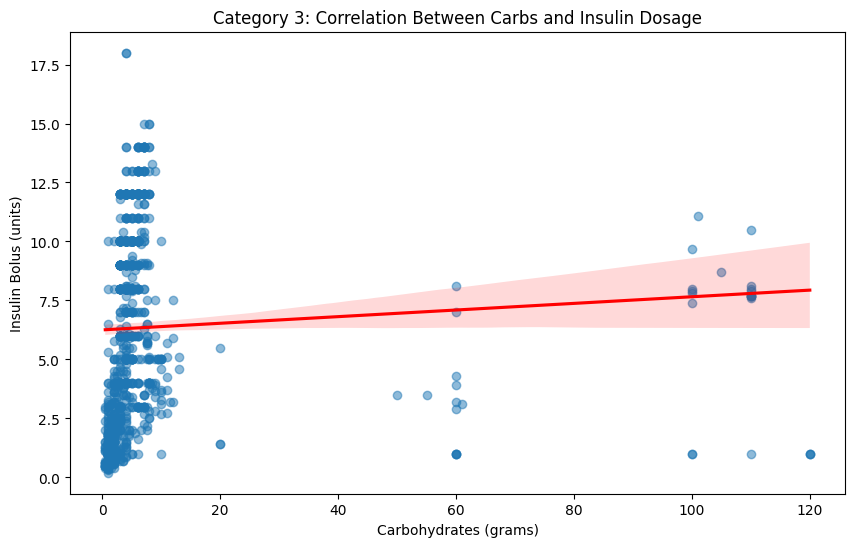

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Loading the file (Correcting the SyntaxError)
file_path = 'Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx'
df = pd.read_excel(file_path)

# 2. Category 3: Analysis (Filtered to show only meaningful data)
# We filter out the 300,000 zeros to see the actual meals and doses
meal_data = df[(df['carb_input'] > 0) & (df['bolus_volume_delivered'] > 0)]

# 3. Generating the Visual Output
plt.figure(figsize=(10, 6))
sns.regplot(data=meal_data, x='carb_input', y='bolus_volume_delivered', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Category 3: Correlation Between Carbs and Insulin Dosage')
plt.xlabel('Carbohydrates (grams)')
plt.ylabel('Insulin Bolus (units)')

# This command forces the window to open and show the chart
plt.show()

### 4. Glucose Range Per Patient

##### **Reason:**
In T1DM, wide glucose swings indicate poor control. Mean alone is misleading — 
a patient could average 120 mg/dL but swing between 40 and 300. Standard 
deviation reveals instability that increases risk of long-term complications 
like nerve damage and organ failure.

            Mean Glucose  Std Dev    Min    Max  Range
patient_id                                            
HUPA0006P         165.20    84.74   42.0  438.0  396.0
HUPA0004P         180.38    83.02   40.0  411.0  371.0
HUPA0016P         150.21    79.84   40.0  362.0  322.0
HUPA0020P         194.28    78.79   40.0  390.0  350.0
HUPA0007P         173.15    78.66   40.0  385.0  345.0
HUPA0014P         188.06    72.46   40.0  443.5  403.5
HUPA0001P         181.44    70.64   40.0  444.0  404.0
HUPA0018P         143.68    70.27   40.0  358.0  318.0
HUPA0017P         200.80    69.45   40.0  401.0  361.0
HUPA0026P         162.99    68.67   40.0  422.0  382.0
HUPA0015P         163.52    68.04   40.0  370.0  330.0
HUPA0024P         166.94    66.55   42.0  359.0  317.0
HUPA0003P         143.27    61.33   44.0  366.0  322.0
HUPA0019P         162.93    60.54   51.0  371.0  320.0
HUPA0002P         113.47    59.15   40.0  310.0  270.0
HUPA0010P         135.89    57.61   41.0  416.0  375.0
HUPA0011P 

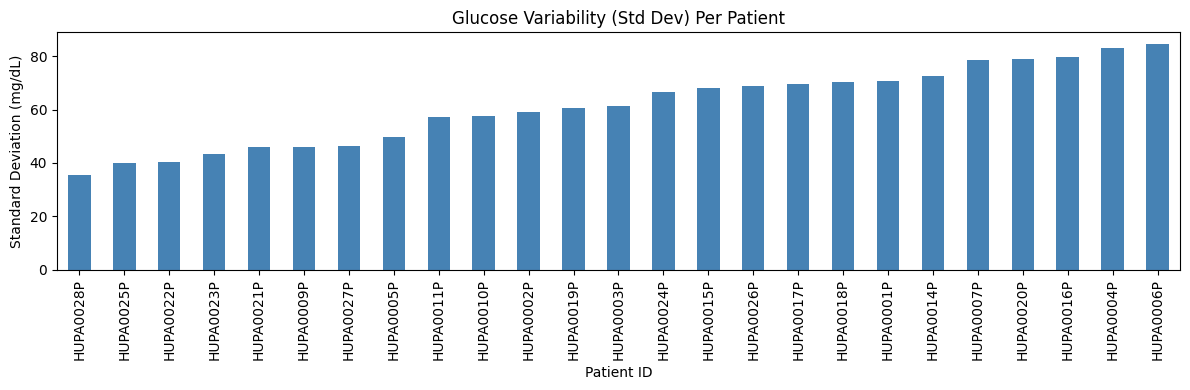

In [4]:
glucose_range = df.groupby('patient_id')['glucose'].agg(['mean', 'std', 'min', 'max']).round(2)
glucose_range.columns = ['Mean Glucose', 'Std Dev', 'Min', 'Max']
glucose_range['Range'] = glucose_range['Max'] - glucose_range['Min']
print(glucose_range.sort_values('Std Dev', ascending=False))

glucose_range['Std Dev'].sort_values().plot(kind='bar', figsize=(12,4), color='steelblue')
plt.title("Glucose Variability (Std Dev) Per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Standard Deviation (mg/dL)")
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: HUPA0006P had the highest glucose 
variability with a standard deviation of 84.74 mg/dL and a range of 396 mg/dL 
(42–438), indicating very poor glucose control. In contrast, HUPA0028P had the 
lowest variability (std = 35.45), suggesting more stable T1DM management. 
Across all 25 patients, average glucose alone does not capture how unstable 
individual patients' control actually is.</span>**

### 5. Hypoglycemia Frequency (Glucose < 70)

##### **Reason:**
Hypoglycemia below 70 mg/dL is a medical emergency in T1DM. It can cause 
seizures, unconsciousness, and death if untreated. Clinical guidelines target 
less than 1% of readings below this threshold. Identifying which patients 
exceed this flag and who are at the highest risk.

   patient_id  pct_hypoglycemic
1   HUPA0002P             23.86
14  HUPA0018P             17.59
18  HUPA0022P             15.39
12  HUPA0016P             15.15
21  HUPA0025P             13.38
3   HUPA0004P              9.70
6   HUPA0007P              8.94
5   HUPA0006P              8.65
8   HUPA0010P              8.33
20  HUPA0024P              7.79
22  HUPA0026P              7.71
2   HUPA0003P              7.03
23  HUPA0027P              6.36
17  HUPA0021P              4.74
19  HUPA0023P              4.31
11  HUPA0015P              4.17
10  HUPA0014P              4.05
16  HUPA0020P              3.56
24  HUPA0028P              3.08
4   HUPA0005P              2.95
15  HUPA0019P              2.69
9   HUPA0011P              2.68
13  HUPA0017P              2.39
0   HUPA0001P              1.44
7   HUPA0009P              0.00


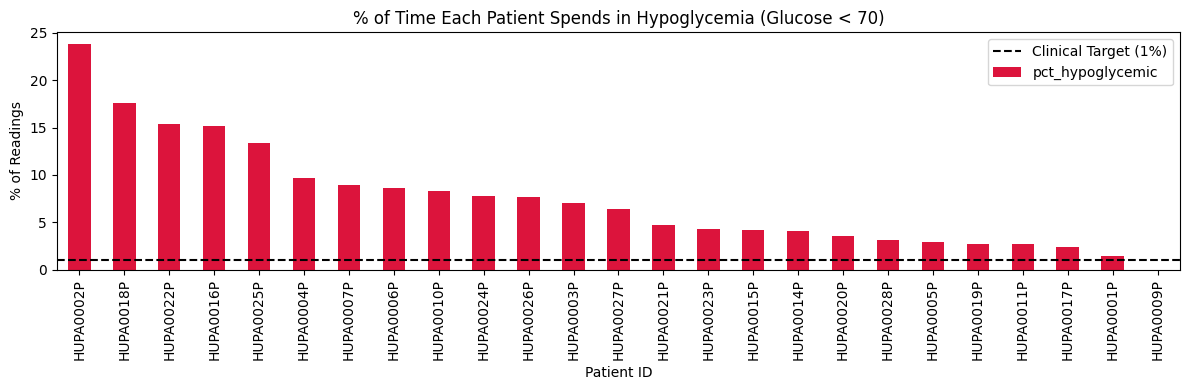

In [5]:
total_readings = df.groupby('patient_id').size()
hypo_readings = df[df['glucose'] < 70].groupby('patient_id').size()

hypo_rate = (hypo_readings / total_readings * 100).fillna(0).round(2)
hypo_df = hypo_rate.reset_index()
hypo_df.columns = ['patient_id', 'pct_hypoglycemic']
print(hypo_df.sort_values('pct_hypoglycemic', ascending=False))

hypo_df.sort_values('pct_hypoglycemic', ascending=False).set_index('patient_id').plot(
    kind='bar', figsize=(12,4), color='crimson', legend=False
)
plt.title("% of Time Each Patient Spends in Hypoglycemia (Glucose < 70)")
plt.xlabel("Patient ID")
plt.ylabel("% of Readings")
plt.axhline(1, color='black', linestyle='--', label='Clinical Target (1%)')
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: 24 out of 25 patients exceed the 
clinical safety threshold of 1% time in hypoglycemia. HUPA0002P is the most 
at-risk patient, spending 23.86% of all readings below 70 mg/dL. HUPA0018P 
(17.59%) and HUPA0022P (15.39%) also show critically high rates. Only 
HUPA0009P stayed above 70 mg/dL at all times (0%). The majority of patients 
in this cohort are at serious risk and may need insulin dose 
adjustments.</span>**

### What is the average and maximum step count per patient?

##### **Reason:** This question provides insights into patients’ physical activity levels by analyzing the average and maximum daily step counts. Physical activity directly affects insulin sensitivity. In T1DM patients, sedentary days are associated with insulin resistance and higher glucose levels. This gives us a picture of how active this patient is, and whether inactivity may be contributing to poor glucose control. In this question we did not calculate minimum step count because the values are 0, this means that the patients had no step count recording or were sedentory.

   patient_id  avg_steps  max_steps
0   HUPA0001P      19.47        621
1   HUPA0002P      39.24        597
2   HUPA0003P      27.41        595
3   HUPA0004P      30.70        599
4   HUPA0005P      13.48        597
5   HUPA0006P      34.01        626
6   HUPA0007P      46.03        560
7   HUPA0009P      47.35        682
8   HUPA0010P      44.62        593
9   HUPA0011P      54.58        627
10  HUPA0014P      35.65        609
11  HUPA0015P      47.73        658
12  HUPA0016P      43.74        617
13  HUPA0017P      27.50        547
14  HUPA0018P      34.66        486
15  HUPA0019P      45.73        637
16  HUPA0020P      36.54        581
17  HUPA0021P      38.16        567
18  HUPA0022P      20.07        544
19  HUPA0023P      15.27        556
20  HUPA0024P      56.31        498
21  HUPA0025P      27.83        842
22  HUPA0026P      47.51        610
23  HUPA0027P      26.50        790
24  HUPA0028P      19.02        702


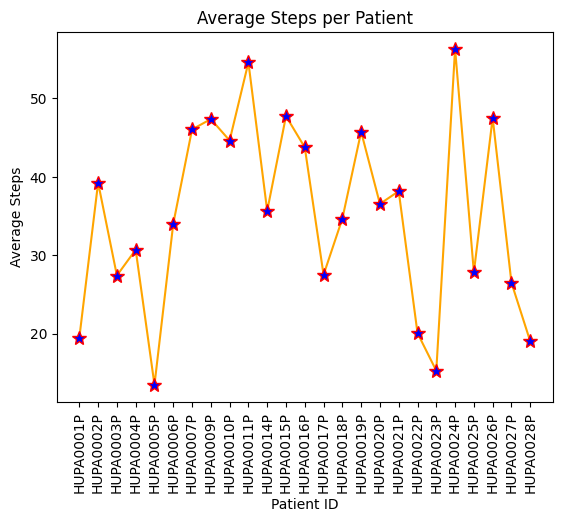

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reading file
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Counting steps per patient
avg_steps_per_patient = df.groupby('patient_id')['steps'].mean().reset_index(name='steps')
max_steps_per_patient = df.groupby('patient_id')['steps'].max().reset_index(name='steps')

# Show all patients
steps_summary = pd.DataFrame({
    'patient_id': avg_steps_per_patient['patient_id'],
    'avg_steps': avg_steps_per_patient['steps'].round(2),
    'max_steps': max_steps_per_patient['steps'].round(2)
})
print(steps_summary)

# Visualization
# Line plot
x = steps_summary['patient_id']
y = steps_summary['avg_steps']

plt.plot(x, y, marker= '*',color='orange', ms =10, mec='r', mfc= 'b') 
plt.title('Average Steps per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Average Steps')
plt.xticks(rotation=90)
plt.show()

### Does increase in glucose cause sleep disturbances or vice verca

### **Reason** 
we may observe:
Patients with high glucose levels tend to report:
shorter sleep duration
poorer sleep quality
higher sleep disturbances

1. Clinical & Health Significance

Sleep and metabolism are deeply linked — poor sleep disrupts hormones like insulin, cortisol, and leptin that directly regulate blood sugar
Identifying this correlation can help doctors predict diabetes risk earlier
Patients with sleep disorders (insomnia, sleep apnea) often show elevated fasting glucose levels


🔬 2. Scientific / Research Value

Helps validate or challenge existing medical literature on sleep-metabolic relationships
Provides data-driven evidence rather than relying on anecdotal observations
Can reveal age-specific patterns — e.g., why the 21-40 group shows peak glucose despite moderate sleep disturbance

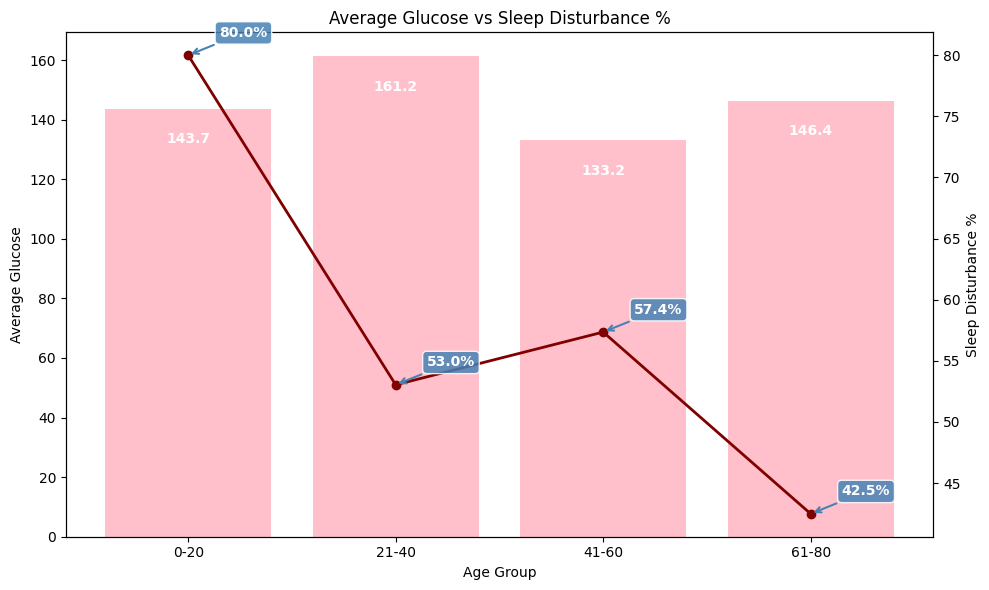

In [11]:
import matplotlib.pyplot as plt

# Example: Grouping by Age Group
# Create age groups
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[0, 20, 40, 60, 80],
    labels=['0-20', '21-40', '41-60', '61-80']
)

# Calculate average glucose
avg_glucose = df.groupby('Age_Group')['glucose'].mean()

# Calculate sleep disturbance percentage
sleep_disturbance = (
    df.groupby('Age_Group')['%_with_sleep_disturbances']
    .mean()
)

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for glucose
bars = ax1.bar(avg_glucose.index.astype(str), avg_glucose.values,color = 'pink')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Glucose')

# Labels inside/on top of each bar
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height - 8,
        f'{height:.1f}',
        ha='center', va='top',
        fontsize=10, color='white', fontweight='bold'
    )

# Create second axis
ax2 = ax1.twinx()

# Line chart for sleep disturbance %
x_positions = list(range(len(sleep_disturbance)))
ax2.plot(
    sleep_disturbance.index.astype(str),
    sleep_disturbance.values,
    marker='o', color='maroon', linewidth=2
)
ax2.set_ylabel('Sleep Disturbance %')

# ✅ Annotate each point on the line chart with an arrow + label box
for i, (x, y) in enumerate(zip(x_positions, sleep_disturbance.values)):
    ax2.annotate(
        f'{y:.1f}%',                        # annotation text
        xy=(x, y),                           # point being annotated
        xytext=(x + 0.15, y + 1.5),         # offset position of label
        fontsize=10,
        color='white',
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',                 # arrow style
            color='steelblue',
            lw=1.5
        ),
        bbox=dict(
            boxstyle='round,pad=0.3',        # rounded box around label
            facecolor='steelblue',           # box fill color
            edgecolor='white',               # box border color
            alpha=0.85                       # slight transparency
        )
    )

# Title
plt.title('Average Glucose vs Sleep Disturbance %')

# Show chart
plt.tight_layout()
plt.show()

<div style="color:green;">

## Average Glucose by Age Group

- The **21–40** age group has the highest average glucose (~160), which is notably elevated and may warrant attention.
- The **41–60** group shows the lowest glucose (~133), which is a bit surprising given that glucose typically trends upward with age.
- The **0–20** and **61–80** groups are fairly similar (~144–147), sitting in a moderate range.

## Sleep Disturbance % (line)

- Sleep disturbance is highest in the **0–20** group (**~80**%), then drops sharply through **21–40** **(~70%)** and **41–60** (**~56%**), hitting its lowest point around **61–80** (**~50%**).
- This is a consistent downward trend — older age groups in this dataset report less sleep disturbance, which runs counter to common assumptions.

## Relationship Between the Two Variables

- There's no clear positive correlation between glucose and sleep disturbance here.
- The **21–40** group has peak glucose but mid-range sleep disturbance, while the **0–20** group has the most disrupted sleep but moderate glucose.
- The **41–60** group is interesting — both glucose and sleep disturbance are at relatively low points, possibly suggesting a healthier cohort in that bracket.

</div>

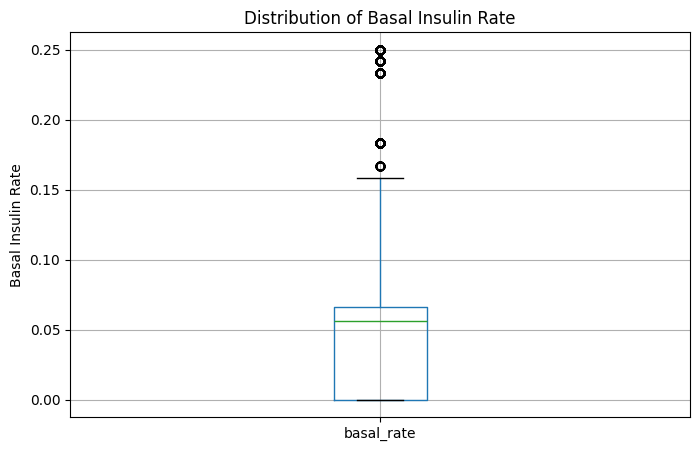

In [17]:
plt.figure(figsize=(8,5))
df.boxplot(column='basal_rate')
plt.ylabel('Basal Insulin Rate')
plt.title('Distribution of Basal Insulin Rate')
plt.show()

#### What is volume of patients according to different blood sugar category ranges

### **Reason** 
Analyzing the volume of patients according to blood sugar range categories is important because it helps healthcare providers understand the overall diabetic condition of the patient population and identify risk patterns.

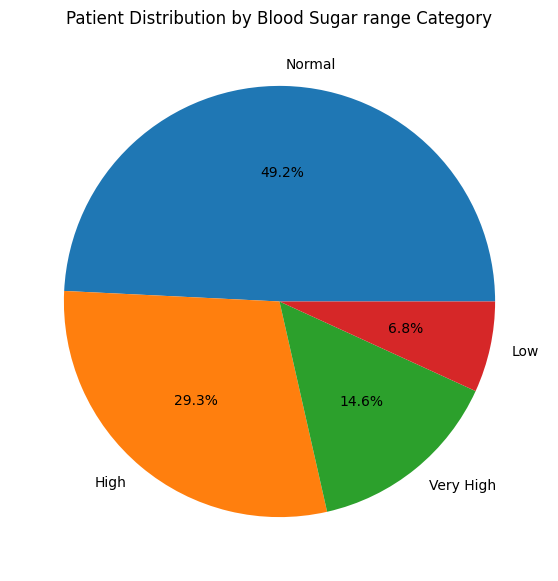

In [24]:
# Create glucose categories
bins = [0, 70, 140, 200, 500]
labels = ['Low', 'Normal', 'High', 'Very High']

df['Blood_Sugar_Category'] = pd.cut(
    df['glucose'],
    bins=bins,
    labels=labels
)

# Count patients
category_counts = df['Blood_Sugar_Category'].value_counts()

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%'
)

plt.title('Patient Distribution by Blood Sugar range Category')
plt.show()

**<span style="color:green">
The distribution is skewed toward elevated glucose levels (High + Very High = ~44%), which is concerning.
While nearly half of patients are normal, the other half shows metabolic imbalance.
The data suggests a need for:
stronger preventive care, better diabetes education, and targeted intervention for high-risk groups.</span>**

### What is the Distribution of Key Health Variables?

#### **Reason**
Insights we Can Derive
Glucose Distribution
Are glucose levels normally distributed?
Are many patients in dangerous ranges?
Heart Rate Distribution
Are abnormal heart rates common?
Activity Distribution
Do patients generally have low activity levels?
Sleep Distribution
Are patients getting healthy sleep duration?
Insulin Distribution
Are insulin doses highly variable?

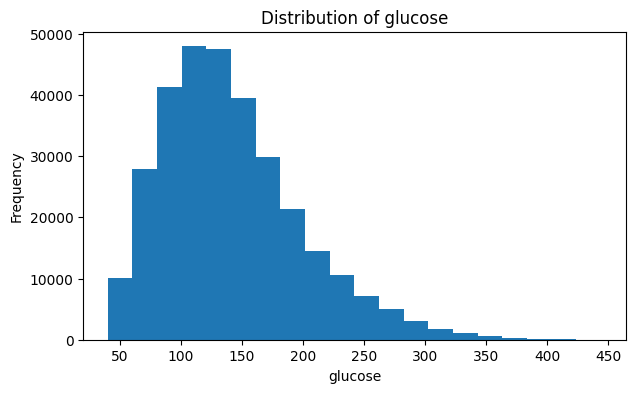

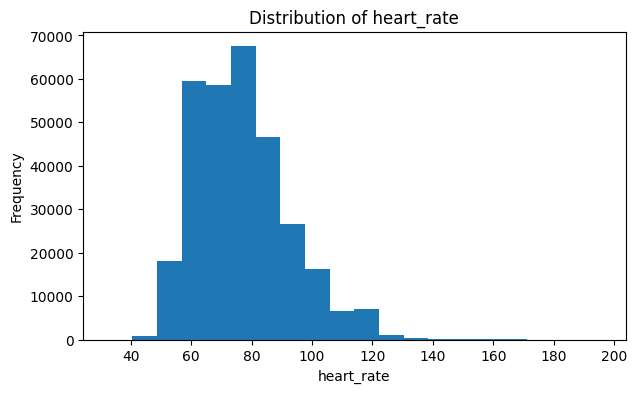

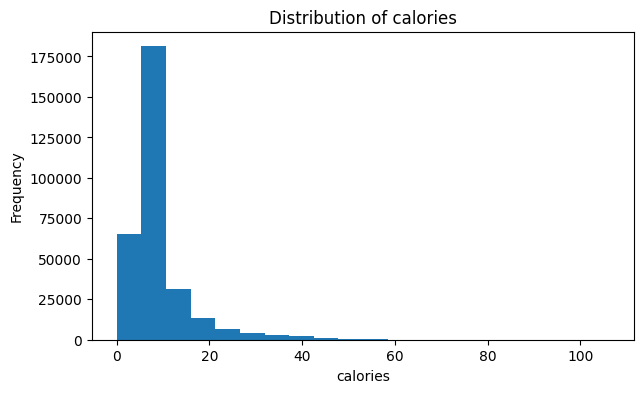

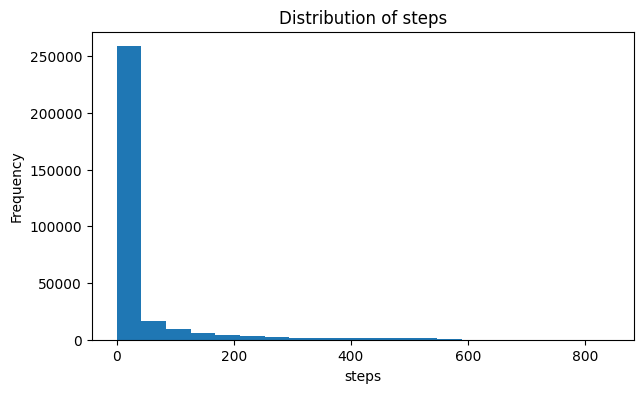

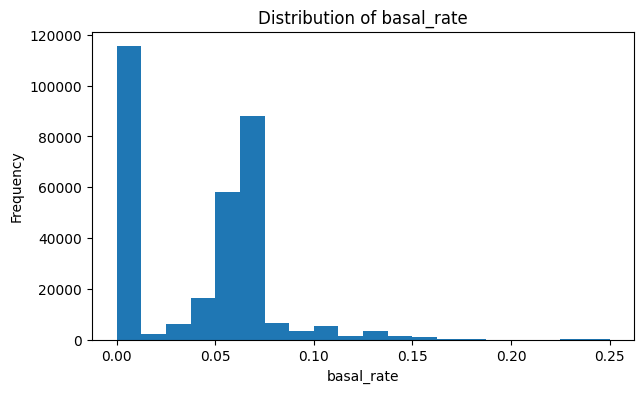

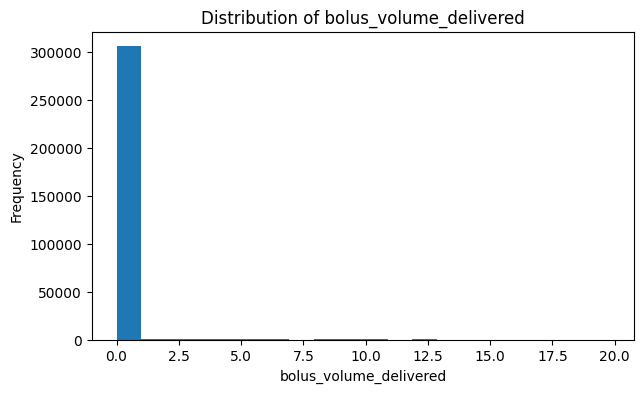

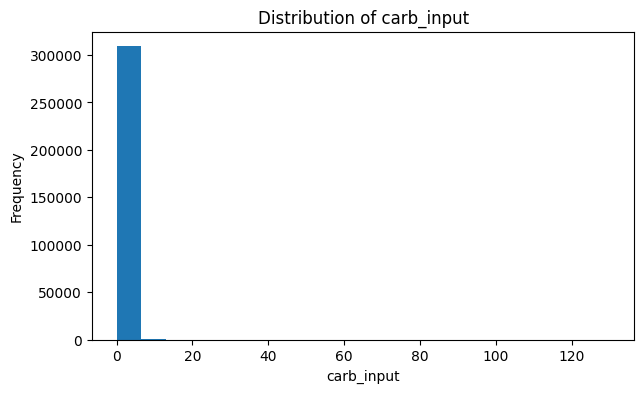

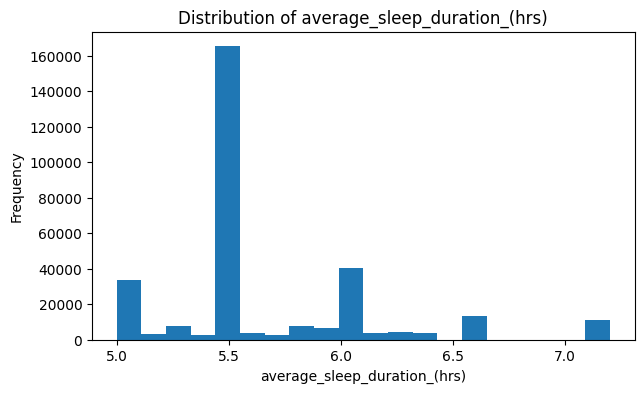

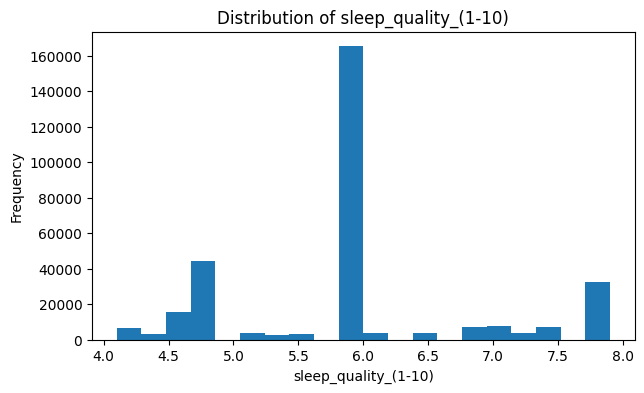

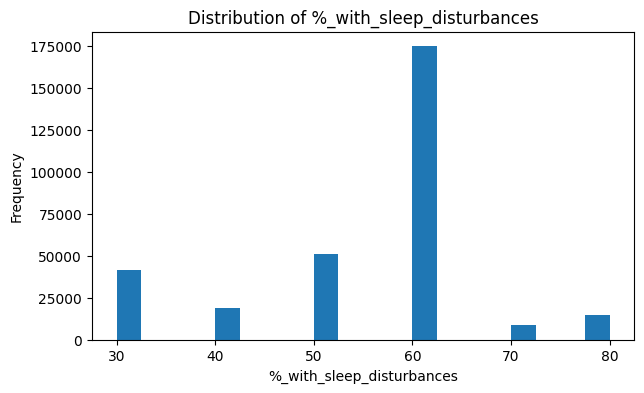

In [27]:
# Key health variables
variables = [
    'glucose',
    'heart_rate',
    'calories',
    'steps',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input',
    'average_sleep_duration_(hrs)',
    'sleep_quality_(1-10)',
    '%_with_sleep_disturbances'
]

# Create histograms
for column in variables:
    
    plt.figure(figsize=(7,4))
    
    plt.hist(df[column].dropna(), bins=20)
    
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')
    
    plt.show()

**<span style="color:green">
Key Insights:
**Glucose Distribution**
: This histogram shows the distribution of glucose levels in the diabetes dataset.
Key Observations
The glucose values are concentrated mostly between 80 and 180.
The highest frequency occurs around 100–130 glucose level, meaning most patients fall in this range.
The distribution is right-skewed (positively skewed):
Many patients have moderate glucose levels.
Fewer patients have extremely high glucose values.
There is a long tail extending toward 400+, indicating some patients experience severe hyperglycemia.

**Heart Rate Distribution**
Distribution of Heart Rate
This is a histogram showing how frequently different heart rate values appear in the dataset. Here's the breakdown:
Central tendency & Peak
The distribution peaks around 75–80 bpm, which is the most common heart rate, with a frequency of roughly 67,000 readings
This aligns well with a normal resting heart rate for adults
Shape of the distribution
The distribution is right-skewed — the bulk of values cluster on the left (lower heart rates) with a long tail stretching toward higher values
The main activity spans roughly 45 to 125 bpm
Notable observations
There is a large gap between ~125 bpm and the x-axis extending to 200 — values above 130 bpm are essentially absent from the dataset
This suggests the data likely represents resting or sedentary heart rate readings, not exercise data
The x-axis extending to 200 is somewhat misleading given no data exists beyond ~130
Overall, this looks like a healthy population's resting heart rate distribution, centered around a normal range.
**Distribution of calories**
Distribution of Calories
This is a histogram showing the frequency of calorie values across the dataset.

Key Insights
1. Extreme concentration at very low values

The vast majority of readings cluster between 0–20 calories
The peak bar (around 5–10 calories) hits nearly 175,000 — by far the dominant bin
The second bar (0–5) sits at **~60,000**, suggesting many near-zero readings

2. Sharply right-skewed distribution

This is one of the most skewed distributions possible — a classic "J-curve" or power law shape
Calories drop off almost immediately after 20, with very little data beyond 40

3. Long, empty tail
The x-axis extends to 100 calories, but data effectively disappears after ~45
This wide empty space suggests either outliers were removed or the axis was auto-scaled

**step distribution**
The distribution is extremely right-skewed, with the overwhelming majority of readings **(~255,000)** concentrated near 0–25 steps, indicating most recorded intervals captured periods of inactivity or rest. Active bursts exist but are very rare, with step counts tapering off sharply after 100 and virtually disappearing beyond 300, suggesting this is frequent interval data (e.g., per-minute wearable readings) rather than daily totals.
**distribution of basal rate**
The distribution is bimodal, with two dominant peaks — a massive spike at **~0.00 (~115,000 readings)** suggesting many patients have zero or near-zero basal insulin, and a second cluster around 0.06–0.07 (~85,000) representing the most common active dosing rate. Values beyond 0.10 drop off sharply and are rare, with the distribution having a long thin tail extending to 0.25, consistent with the outliers seen in the earlier box plot.
**Distribution of Bolus_volume_delivered**
Key Insights
1. Dominated by zero/near-zero values

The single towering bar suggests the vast majority of time intervals have no bolus delivered
This makes physiological sense — bolus insulin is only given at mealtimes or corrections, not continuously

2. Virtually nothing beyond 2.5 units

The x-axis extends all the way to 20 units, but data is essentially flat after ~2
This extreme empty space suggests either very conservative dosing or the dataset captures frequent short intervals where most have no bolus event
**Carb-input Distribution**
~310,000 readings are at or near zero — the vast majority of time intervals had no carbs logged, which is expected since meals are episodic events, not continuous.
Non-zero carb entries are extremely rare, with values tapering off quickly after ~5g and virtually nothing beyond 20g, despite the x-axis extending to 120g — suggesting either very small snack-level entries dominate when logging does occur, or many meals went unlogged in the dataset.

This pattern mirrors the bolus volume chart almost exactly, which makes clinical sense — carb intake and bolus delivery should correlate closely in insulin pump therapy.

1. Average Sleep Duration (hrs)

Massive spike at 5.5 hrs **(~160,000)** — this is the single dominant sleep duration in the dataset
Secondary bumps at 5.0 **(~35,000)** and 6.0 **(~40,000)**
Very few patients sleep beyond 6.5–7.0 hrs
⚠️ Concerning — the majority are sleeping below the recommended 7–9 hours, suggesting chronic mild sleep deprivation in this population


2. Sleep Quality (1–10)

Bimodal — two clear peaks at 5.0 **(~42,000)** and 6.0 **(~160,000)**
Score of 6 dominates overwhelmingly — most patients rate sleep as just above average
Small uptick at 8.0 **(~35,000)** representing a minority with good sleep quality
No scores below 4 or above 8 — a narrow, mediocre quality range


3. % With Sleep Disturbances

60% disturbance rate is the dominant value **(~170,000)** — most patients experience disrupted sleep
Secondary clusters at 30% **(~42,000)** and 50% **(~50,000)**
Small groups at 70–80% indicating severely disrupted sleep
⚠️ A 60% disturbance rate is very high and likely linked to nighttime glucose fluctuations common in diabetic patients


Overall Sleep Takeaway
MetricDominant ValueConcern LevelSleep Duration5.5 hrs🔴 HighSleep Quality6/10🟡 ModerateSleep Disturbances60%🔴 High </span>**